# Unsupervised Learning with Scikit-Learn

## K-Means Clustering + PCA

This notebook demonstrates two important unsupervised learning techniques:

- K-Means Clustering
- Principal Component Analysis (PCA)

The dataset is generated inside the notebook so no external CSV file is required.


## 1. Import Libraries

We use:
- `numpy` for numerical operations
- `pandas` for tabular data
- `matplotlib` for visualization
- `make_blobs` for creating sample clustering data
- `StandardScaler` for feature scaling
- `KMeans` for clustering
- `PCA` for dimensionality reduction


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


## 2. Create an Unlabeled Dataset

Unsupervised learning does not require a target column (`y`) during model training.

Here, `make_blobs()` creates numerical observations that naturally form several groups.


In [2]:
X, _ = make_blobs(
    n_samples=500,
    centers=4,
    n_features=4,
    cluster_std=1.4,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
)

df.head()


,Feature_1,Feature_2,Feature_3,Feature_4
0,-7.635291,-7.969736,-8.564144,5.953801
1,7.868669,-7.637589,-6.186569,-3.617409
2,6.392798,-3.828391,-7.267851,-7.450779
3,0.375849,11.471763,4.291329,3.333369
4,2.129851,2.365262,-8.193537,8.706938


## 3. Check the Dataset

The dataset contains only input features. There is no target label used by the clustering algorithm.


In [3]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


Shape: (500, 4)

First 5 rows:
   Feature_1  Feature_2  Feature_3  Feature_4
0  -7.635291  -7.969736  -8.564144   5.953801
1   7.868669  -7.637589  -6.186569  -3.617409
2   6.392798  -3.828391  -7.267851  -7.450779
3   0.375849  11.471763   4.291329   3.333369
4   2.129851   2.365262  -8.193537   8.706938


## 4. Feature Scaling

Scaling is important when features have different ranges because distance-based algorithms such as K-Means can be affected by feature magnitude.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (500, 4)


## 5. K-Means Clustering

K-Means divides observations into a specified number of clusters.

The algorithm repeatedly:
1. Initializes cluster centroids.
2. Assigns each sample to the nearest centroid.
3. Recalculates the centroids.
4. Repeats until convergence or the iteration limit is reached.


In [5]:
kmeans = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df.head())


   Feature_1  Feature_2  Feature_3  Feature_4  Cluster
0  -7.635291  -7.969736  -8.564144   5.953801        3
1   7.868669  -7.637589  -6.186569  -3.617409        2
2   6.392798  -3.828391  -7.267851  -7.450779        2
3   0.375849  11.471763   4.291329   3.333369        0
4   2.129851   2.365262  -8.193537   8.706938        1


## 6. Cluster Centroids

`cluster_centers_` contains the final centroid of each cluster in the scaled feature space.


In [6]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)


Cluster Centers:
[[-0.45190506  1.29568533  1.64976883 -0.19151593]
 [ 0.44322059  0.59123821 -0.75652156  1.00865863]
 [ 1.29896402 -0.84417611 -0.24883833 -1.50599005]
 [-1.29027954 -1.04274743 -0.64440894  0.68884734]]


## 7. Inertia

Inertia is the sum of squared distances of samples from their assigned cluster centroid.

Lower inertia means the samples are closer to their assigned centroids, but inertia alone should not be used to decide the ideal number of clusters.


In [7]:
print("Inertia:", kmeans.inertia_)


Inertia: 106.38214651466501


## 8. Elbow Method

The Elbow Method calculates K-Means inertia for several values of `k`.

The point where the reduction in inertia begins to slow down can be considered a useful candidate for the number of clusters.


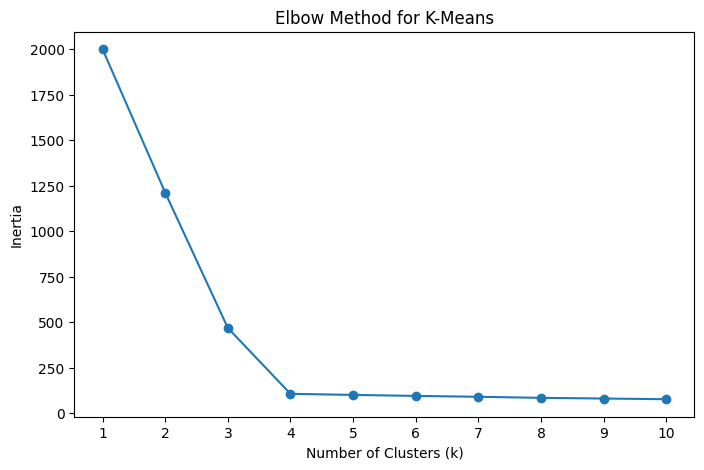

In [8]:
inertias = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.show()


## 9. Visualize K-Means Clusters with PCA

The dataset has four dimensions, so it cannot be directly shown on a normal 2D plot.

PCA reduces the four features to two principal components for visualization.


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)


Original shape: (500, 4)
PCA shape: (500, 2)


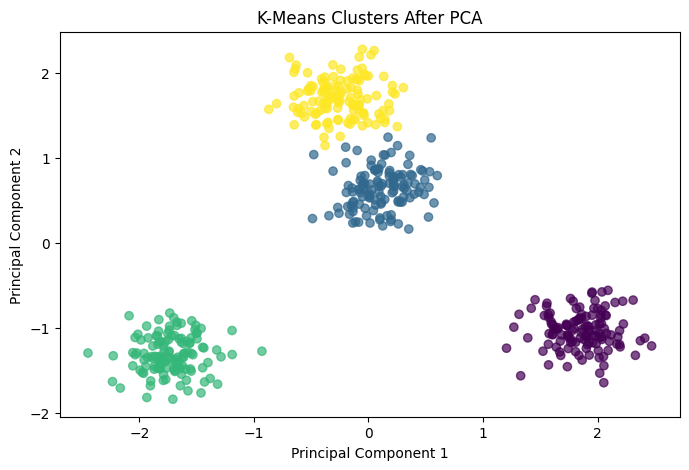

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters After PCA")
plt.show()


## 10. Explained Variance

`explained_variance_ratio_` tells us how much of the dataset's variance is represented by each selected principal component.


In [11]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      pca.explained_variance_ratio_.sum())


Explained variance ratio:
[0.42098604 0.39471711]

Total variance explained by 2 components: 0.8157031527978071


## 11. PCA Components

`components_` contains the directions of the principal components in the original feature space.


In [12]:
print("PCA Components:")
print(pca.components_)


PCA Components:
[[-0.41895276  0.63974384  0.55057977  0.33476608]
 [-0.51882724 -0.2645387  -0.48436677  0.65286017]]


## 12. Complete PCA + K-Means Workflow

A common unsupervised learning workflow is:

Raw features
→ Feature Scaling
→ PCA (optional)
→ K-Means
→ Cluster assignments

PCA can be used for dimensionality reduction or visualization. It is not required for K-Means itself.


In [13]:
X_pca_scaled = PCA(n_components=2).fit_transform(X_scaled)

final_model = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=42
)

final_clusters = final_model.fit_predict(X_pca_scaled)

print("Cluster labels:")
print(final_clusters[:20])


Cluster labels:
[3 2 2 0 1 0 1 1 3 0 3 2 0 3 2 0 1 3 1 1]


## 13. Important Notes

- K-Means is an unsupervised clustering algorithm.
- K-Means requires the number of clusters (`k`) to be specified.
- K-Means is distance-based, so feature scaling can be important.
- `inertia_` measures within-cluster squared distances.
- PCA is a dimensionality-reduction technique.
- PCA creates new features called principal components.
- PCA does not use a target label.
- PCA can help visualize high-dimensional data.
- PCA and K-Means solve different problems and can be used together.


## Conclusion

This notebook demonstrates a practical Scikit-Learn workflow for unsupervised learning using **K-Means Clustering and PCA**.

K-Means groups similar observations, while PCA reduces the number of dimensions while preserving as much variance as possible in the selected components.
